In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyreadstat import read_sav
from pyreadstat import metadata_container

np.random.seed(42)

Загрузка датасета

In [2]:
df: pd.DataFrame; meta: metadata_container
df, meta = read_sav('data.sav')
df = df.drop('k4_new', axis=1)
print(df.shape)

NUM_COLS = df.columns[1:-1]
df.head()

(2695, 22)


,Cреднеспис.числ.работн,k1,k2,k3,k4,k5,k6,k7,k8,k9,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.942380,0.060563,0.678302,-0.161531,0.202055,0.165019,0.399033,0.799019,5.426569,...,1.082798,0.655937,4.454819,3.975687,0.892446,1007.536232,0.076738,0.055049,0.034904,5.0
1,255.0,1.980494,0.274382,0.916775,0.624425,0.089377,0.220648,0.000000,0.933519,14.041958,...,1.123828,0.705951,10.618881,12.295547,1.157895,357.294118,0.116068,0.059740,0.025647,5.0
2,114.0,0.374160,0.001494,0.085138,-1.504990,0.235739,0.508929,0.888889,0.779049,5.017007,...,1.185374,0.123415,0.794785,6.258929,7.875000,36.894737,-0.584879,0.010563,0.000000,5.0
3,365.0,7.859079,0.831978,2.449864,0.875862,0.059439,0.030030,0.011111,0.942010,16.244444,...,1.309449,2.804607,48.363889,26.142643,0.540541,33.676983,0.171731,0.496295,0.312415,5.0
4,168.0,1.779376,0.005596,0.883293,0.527853,0.135491,0.886686,0.489796,0.887341,10.558673,...,0.994832,0.473041,5.628827,3.125354,0.555241,19.103896,0.064809,0.025726,0.011839,5.0


Нахождение аномальных наблюдений при помощи алгоритма Isolation Forest

In [3]:
from sklearn.ensemble import IsolationForest

df_train: pd.DataFrame; df_test: pd.DataFrame
print(f"Shape: {df.shape}")

clf = IsolationForest(
    n_estimators=256,           # Больше деревьев = стабильнее
    max_samples='auto',         # Можно попробовать 256, 512, 1024
    contamination=0.05,       # или 0.05, или подобрать вручную
    max_features=0.8,           # Используем не все признаки сразу (боремся с шумом)
    bootstrap=False,
    random_state=42
)

clf.fit(df[NUM_COLS])
outliers_train: np.ndarray = clf.predict(df[NUM_COLS])

print(f"Number of outliers in df: {np.abs( outliers_train[outliers_train == -1].sum() )}")

Shape: (2695, 22)
Number of outliers in df: 135


Цензурирование данных:

In [4]:

outliers_mask = (outliers_train == -1)

percentiles = {}
for col in NUM_COLS:
    p_low: float = df[col][outliers_mask != 1].min()
    p_high = df[col][outliers_mask != 1].max()
    percentiles[col] = (p_low, p_high)

df_clean: pd.DataFrame = df.copy()
for col in NUM_COLS:
    low, high = percentiles[col]
    col_data = df_clean[col][outliers_mask]
    col_data[col_data < low] = low
    col_data[col_data > high] = high
    df_clean.loc[outliers_mask, col] = col_data

    
#df_clean = df[outliers_mask != 1]
"""

df_clean = df.copy()
outliers_mask = (outliers_train == -1)

for col in NUM_COLS:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    # Применяем clip только к выбросам
    df_clean.loc[outliers_mask, col] = df_clean.loc[outliers_mask, col].clip(lower, upper)
"""

'\n\ndf_clean = df.copy()\noutliers_mask = (outliers_train == -1)\n\nfor col in NUM_COLS:\n    lower = df_clean[col].quantile(0.01)\n    upper = df_clean[col].quantile(0.99)\n    # Применяем clip только к выбросам\n    df_clean.loc[outliers_mask, col] = df_clean.loc[outliers_mask, col].clip(lower, upper)\n'

Стандартизация:

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()

scaler.fit(df_clean)

df_array: np.ndarray = scaler.transform(df_clean)
df_stand: pd.DataFrame = pd.DataFrame(df_array,
                                             columns=df_clean.columns,
                                               index=df_clean.index)
df_stand.head()

,Cреднеспис.числ.работн,k1,k2,k3,k4,k5,k6,k7,k8,k9,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,1.907025,-0.675745,-0.366427,-0.160390,-0.321278,-0.728808,-0.342690,1.007154,0.730890,-0.197103,...,-0.459226,-0.779117,-0.721057,-0.714123,-0.446798,0.356741,0.197595,-0.259591,-0.243582,-1.5
1,-0.377856,0.003808,0.091083,0.115689,0.941971,-1.297990,-0.081589,-0.780436,1.418055,1.040204,...,-0.388731,-0.707685,0.089138,-0.090392,-0.352455,0.069029,0.557174,-0.209387,-0.315155,-1.5
2,-0.433021,-1.047704,-0.492820,-0.847094,-2.480589,-0.558656,1.271497,3.201610,0.628864,-0.255922,...,-0.282988,-1.539686,-1.202126,-0.542951,2.034852,-0.072738,-5.851306,-0.735735,-0.513461,-1.5
3,-0.334818,3.851951,1.284178,1.890542,1.346100,-1.449216,-0.976280,-0.730660,1.461435,1.356516,...,-0.069809,2.289705,5.050281,0.947709,-0.571867,-0.074162,1.066070,4.463192,1.902120,-1.5
4,-0.411894,-0.127844,-0.484043,0.076928,0.786752,-1.065047,3.044553,1.413753,1.182127,0.539949,...,-0.610363,-1.040336,-0.566747,-0.777871,-0.566643,-0.080610,0.088524,-0.573443,-0.421925,-1.5


Корреляционный анализ:

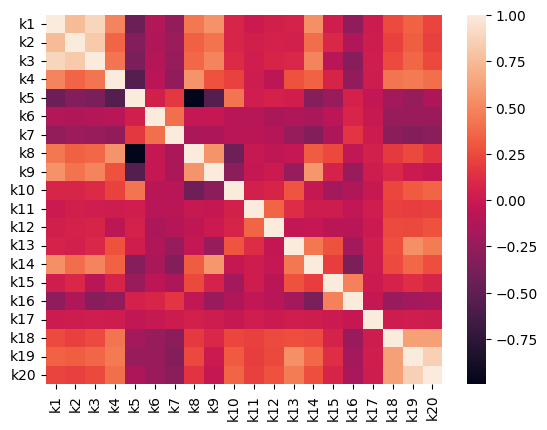

-0.9963776136177028
K1 & 1.0 & 0.75 & 0.89 & 0.49 & -0.44 & -0.12 & -0.26 & 0.44 & 0.55 & 0.08 \\ 
K2 & 0.75 & 1.0 & 0.82 & 0.35 & -0.33 & -0.13 & -0.22 & 0.33 & 0.41 & 0.08 \\ 
K3 & 0.89 & 0.82 & 1.0 & 0.42 & -0.37 & -0.11 & -0.24 & 0.37 & 0.49 & 0.1 \\ 
K4 & 0.49 & 0.35 & 0.42 & 1.0 & -0.56 & -0.09 & -0.26 & 0.56 & 0.28 & 0.22 \\ 
K5 & -0.44 & -0.33 & -0.37 & -0.56 & 1.0 & 0.04 & 0.17 & -1.0 & -0.56 & 0.42 \\ 
K6 & -0.12 & -0.13 & -0.11 & -0.09 & 0.04 & 1.0 & 0.39 & -0.03 & -0.03 & -0.08 \\ 
K7 & -0.26 & -0.22 & -0.24 & -0.26 & 0.17 & 0.39 & 1.0 & -0.16 & -0.15 & -0.09 \\ 
K8 & 0.44 & 0.33 & 0.37 & 0.56 & -1.0 & -0.03 & -0.16 & 1.0 & 0.56 & -0.43 \\ 
K9 & 0.55 & 0.41 & 0.49 & 0.28 & -0.56 & -0.03 & -0.15 & 0.56 & 1.0 & -0.3 \\ 
K10 & 0.08 & 0.08 & 0.1 & 0.22 & 0.42 & -0.08 & -0.09 & -0.43 & -0.3 & 1.0 \\ 


In [6]:
corr_matrix = df_stand[NUM_COLS].corr()
sns.heatmap(corr_matrix)
plt.show()
print(df_stand[NUM_COLS].corr()['k5']['k8'])

for i in range(corr_matrix.shape[0] // 2):
    print(f'K{i+1}', end=' ')
    for j in range(corr_matrix.shape[1] // 2):
        print('&', np.round(corr_matrix.iloc[i, j], 2), end=' ')
    print('\\\\ ')


In [7]:
df_clean.drop('k8', axis=1, inplace=True)
NUM_COLS = df_clean.columns[1:-1]

Тест Бартлетта и Кайзера-Малкина-Олкина:

In [8]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

def bartlett_test_of_sphericity(data: pd.DataFrame, selected_columns: list):
    chi_square_value, p_value = calculate_bartlett_sphericity(data[selected_columns])
    return chi_square_value, p_value

def kmo_test(data: pd.DataFrame, selected_columns: list = None):
    _, kmo_model = calculate_kmo(data[selected_columns])
    return kmo_model

print(bartlett_test_of_sphericity(df_clean, NUM_COLS))
print(kmo_test(df_clean, NUM_COLS))

(np.float64(28918.669327786163), np.float64(0.0))
0.7190267590352357


In [9]:
from sklearn.decomposition import PCA

n_pca_components: int = 6
total_variance = np.sum(np.var(df_stand[NUM_COLS], axis=0, ddof=1))

pca = PCA(n_components=n_pca_components, random_state=42)
pca.fit(df_stand[NUM_COLS])
pca_eigen_values: np.ndarray = pca.explained_variance_

pca_res_df = pd.DataFrame(
    {"Eigen values": pca_eigen_values,
        "Explained variance ratio": pca.explained_variance_ratio_,
            "Cumsum of explained variance ratio": np.cumsum(pca.explained_variance_ratio_)},
    index=[i for i in range(n_pca_components)]
)
print(pca_res_df)

pca_array: np.ndarray = pca.transform(df_stand[NUM_COLS])
pca_columns: list[str] = ['pca_' + str(i + 1) for i in range(n_pca_components)]
df_pca: pd.DataFrame = pd.DataFrame(pca_array, columns=pca_columns, index=df_stand.index)
print("\nDataframe in principal components space:")
print(f"Shape: {df_pca.shape}")
print(df_pca.head())



   Eigen values  Explained variance ratio  Cumsum of explained variance ratio
0      5.161034                  0.271533                            0.271533
1      2.740613                  0.144189                            0.415722
2      1.723147                  0.090658                            0.506380
3      1.413642                  0.074375                            0.580755
4      1.151165                  0.060565                            0.641320
5      1.130200                  0.059462                            0.700782

Dataframe in principal components space:
Shape: (2695, 6)
      pca_1     pca_2     pca_3     pca_4     pca_5     pca_6
0 -1.077042  0.606572 -0.362563  0.292559 -0.657736  0.843046
1  0.898281  1.404652  0.416463  0.424126 -0.985419  0.467253
2 -5.451080  2.759743  0.160114 -0.186209  1.741680  0.697630
3  7.971213  0.009512  1.420543 -1.437091 -0.451176 -0.363876
4 -1.017420  2.038756 -0.848348 -0.880456 -0.083863  3.117255


In [10]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)

print(loadings_df[loadings_df >= 0.5])

          PC1       PC2       PC3       PC4       PC5       PC6
k1   0.781828       NaN       NaN       NaN       NaN       NaN
k2   0.685293       NaN       NaN       NaN       NaN       NaN
k3   0.771999       NaN       NaN       NaN       NaN       NaN
k4   0.681043       NaN       NaN       NaN       NaN       NaN
k5        NaN       NaN       NaN       NaN       NaN       NaN
k6        NaN       NaN       NaN       NaN       NaN  0.605752
k7        NaN       NaN       NaN       NaN       NaN       NaN
k9        NaN  0.672759       NaN       NaN       NaN       NaN
k10       NaN       NaN       NaN       NaN       NaN       NaN
k11       NaN       NaN       NaN  0.576396       NaN       NaN
k12       NaN       NaN       NaN  0.711492       NaN       NaN
k13       NaN       NaN       NaN       NaN       NaN       NaN
k14  0.688338       NaN       NaN       NaN       NaN       NaN
k15       NaN       NaN  0.865200       NaN       NaN       NaN
k16       NaN       NaN  0.595672       

Вращение факторов varimax

In [11]:
from factor_analyzer import Rotator

rotator = Rotator(method='varimax')
rotated_loadings = rotator.fit_transform(loadings)

rotated_eig_vals = np.sum(rotated_loadings**2, axis=0)      # сумма квадратов по строкам (признакам)

components = [f"PC{i+1}_rot" for i in range(len(rotated_eig_vals))]
df_eigen = pd.DataFrame({
    "Component": components,
    "Eigenvalue": rotated_eig_vals,
    "Variance": (rotated_eig_vals / total_variance),
    "Cumulative": np.cumsum(rotated_eig_vals / total_variance)
})
print(df_eigen)
df_eigen.shape

  Component  Eigenvalue  Variance  Cumulative
0   PC1_rot    3.420836  0.179977    0.179977
1   PC2_rot    3.299883  0.173614    0.353591
2   PC3_rot    1.583259  0.083299    0.436889
3   PC4_rot    1.566401  0.082412    0.519301
4   PC5_rot    1.843476  0.096989    0.616290
5   PC6_rot    1.605946  0.084492    0.700782


(6, 4)

In [12]:
df_rotated_loadings = pd.DataFrame(
    rotated_loadings,
    columns=[f'PC{i+1}_rot' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)
print(df_rotated_loadings[df_rotated_loadings >= 0.4])

      PC1_rot  PC2_rot   PC3_rot   PC4_rot   PC5_rot   PC6_rot
k1   0.903294      NaN       NaN       NaN       NaN       NaN
k2   0.891228      NaN       NaN       NaN       NaN       NaN
k3   0.919198      NaN       NaN       NaN       NaN       NaN
k4        NaN      NaN       NaN       NaN       NaN       NaN
k5        NaN      NaN       NaN       NaN  0.772413       NaN
k6        NaN      NaN       NaN       NaN       NaN  0.749057
k7        NaN      NaN       NaN       NaN       NaN  0.716314
k9   0.569708      NaN       NaN       NaN       NaN       NaN
k10       NaN      NaN       NaN       NaN  0.716429       NaN
k11       NaN      NaN       NaN  0.653886       NaN       NaN
k12       NaN      NaN       NaN  0.806904       NaN       NaN
k13       NaN      NaN       NaN       NaN       NaN       NaN
k14  0.404868      NaN       NaN       NaN       NaN       NaN
k15       NaN      NaN  0.823478       NaN       NaN       NaN
k16       NaN      NaN  0.855401       NaN       NaN   

In [13]:
# New PCA space
T = np.linalg.pinv(loadings) @ rotated_loadings
rot_pca_array = pca_array @ T
rot_pca_df: pd.DataFrame = pd.DataFrame(
    rot_pca_array,
    columns=[f"PCA{i+1}_rot" for i in range(pca.n_components_)], 
    index=df_stand.index
)
rot_pca_df.head()

,PCA1_rot,PCA2_rot,PCA3_rot,PCA4_rot,PCA5_rot,PCA6_rot
0,-0.741276,0.856833,-0.583530,0.054671,-0.724642,0.857951
1,0.702301,0.156428,-0.271913,-0.117895,-1.906305,-0.288317
2,-1.612726,4.751083,1.630672,-1.187798,0.394334,3.392900
3,4.877355,-5.426652,-0.030959,-0.951195,-2.010121,-3.126662
4,0.116485,0.647988,-0.973439,-1.000903,-1.659975,3.357456


Добавление интегрального показателя:

In [14]:
integral_score = np.zeros(rot_pca_df.shape[0])
for i, col in enumerate(rot_pca_df.columns):
    integral_score += rot_pca_df[col] * (rotated_eig_vals[i] / total_variance)

#integral_score_normalized = 50 + (integral_score - integral_score.mean()) / integral_score.std() * 10
df_final = df_stand.copy()
df_final['int_score'] = integral_score

In [15]:
from sklearn.cluster import KMeans

#clusterer = HDBSCAN(min_cluster_size=5, copy=False)
clusterer = KMeans(n_clusters=4, random_state=42)
clusterer.fit(rot_pca_df)

# Результаты
labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # -1 метка для шума
n_noise = list(labels).count(-1)

print(f"Количество найденных кластеров: {n_clusters}")
print(f"Количество точек, отнесённых к шуму: {n_noise}")
print(f"Метки кластеров (первые 10): {labels[:10]}")
print("Центры кластеров:")
for i in set(labels):
    print(i+1, rot_pca_df[labels == i].mean(axis=0).to_numpy())
print("\nЧисло наблюдений в каждом кластере:")
#print(clusterer.probabilities_[:10])

for i in set(labels):
    print(i, np.sum(labels == i), np.round(np.sum(labels == i)/len(labels), 4))

df_final['label'] = labels
#plt.scatter(df_pca['pca_1'], df_pca['pca_2'], с=labels, cmap='viridis')

Количество найденных кластеров: 4
Количество точек, отнесённых к шуму: 0
Метки кластеров (первые 10): [2 2 1 0 1 0 2 0 2 2]
Центры кластеров:
1 [ 4.40686507 -0.90017415 -0.31900646 -0.19528983 -1.30215887 -0.88311072]
2 [-1.21406471  2.14512515  0.71202741 -0.34805277  0.48858657  1.4505496 ]
3 [-0.45257488  0.23149934 -0.19793763 -0.13144245 -0.0671017  -0.09658048]
4 [ 0.11180827 -2.25027907 -0.01994576  0.78514997  0.3630827  -0.72068354]

Число наблюдений в каждом кластере:
0 271 0.1006
1 519 0.1926
2 1377 0.5109
3 528 0.1959


In [16]:
mean_int_per_label = df_final.groupby('label')['int_score'].mean()
mean_int_per_label

label
0    0.393275
1    0.354494
2   -0.083250
3   -0.333189
Name: int_score, dtype: float64

Переупорядочивание меток кластеров:

In [17]:
sorted_labels = mean_int_per_label.sort_values(ascending=False).index.tolist()
label_mapping = {old: new+1 for new, old in enumerate(sorted_labels)}
df_final['label'] = df_final['label'].map(label_mapping)
df_final.groupby('label')['int_score'].mean()

label
1    0.393275
2    0.354494
3   -0.083250
4   -0.333189
Name: int_score, dtype: float64

In [18]:
df_final_int_stat = pd.DataFrame(
    {
        'Mean': np.round(df_final.groupby('label')['int_score'].mean(), 4),
        'Median': np.round(df_final.groupby('label')['int_score'].median(), 4),
        'Min': np.round(df_final.groupby('label')['int_score'].min(), 4),
        'Max': np.round(df_final.groupby('label')['int_score'].max(), 4),
        'Std': np.round(df_final.groupby('label')['int_score'].std(), 4)
    }
)

df_final_int_stat

,Mean,Median,Min,Max,Std
label,,,,,
1,0.3933,0.2973,-0.6078,1.9953,0.4988
2,0.3545,0.2840,-0.1064,1.5097,0.2824
3,-0.0833,-0.0788,-0.6822,1.0173,0.2126
4,-0.3332,-0.3274,-2.2393,0.8932,0.3091


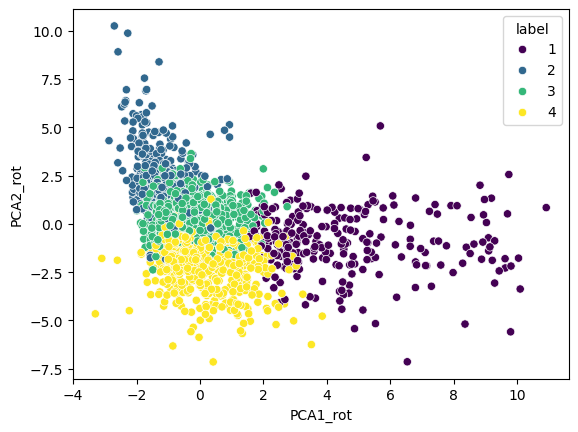

In [19]:
sns.scatterplot(rot_pca_df, x='PCA1_rot', y='PCA2_rot', hue=df_final['label'], palette='viridis')
plt.show()

Иерархический кластерный анализ

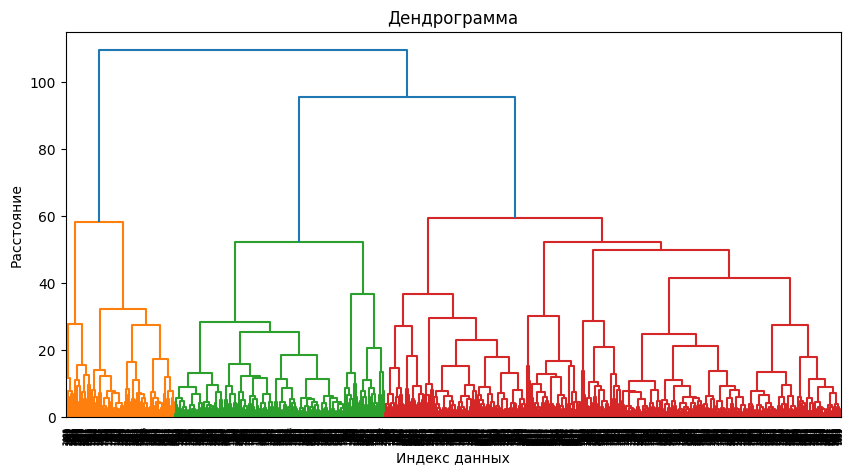

In [20]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

clustering = AgglomerativeClustering(4, metric='euclidean', linkage='ward')
labels = clustering.fit_predict(rot_pca_df)
# 2. Для дендрограммы используем SciPy
Z = linkage(rot_pca_df.values, method='ward')

# Визуализация дендрограммы
plt.figure(figsize=(10, 5))
plt.title('Дендрограмма')
plt.xlabel('Индекс данных')
plt.ylabel('Расстояние')
dendrogram(Z)
plt.show()
df_hierarchy = df_final.copy()
df_hierarchy['label'] = labels + 1

In [21]:
print("Центры кластеров:")
for i in set(labels):
    print(i+1, rot_pca_df[labels == i].mean(axis=0).to_numpy())

Центры кластеров:
1 [ 3.32633331 -0.3989619  -0.47208367 -0.24020973 -1.26178865 -0.64623989]
2 [-0.53049037  0.02335432  0.16695406  0.17704223  0.1074679  -0.5694389 ]
3 [-0.94985674  1.54390516  0.22709438 -0.46698606  0.15802998  1.38924684]
4 [ 0.01532763 -2.05049717 -0.34609974  0.48848658  0.50736634 -0.29472902]


In [22]:
print("Число наблюдений в каждом кластере:")
for i in set(labels):
    print(i+1, np.sum(labels == i), np.round(np.sum(labels == i)/len(labels), 4))

print("Среднее значение интегрального показателя в каждом кластере:")
mean_int_per_label_hier = df_hierarchy.groupby('label')['int_score'].mean()
print(mean_int_per_label_hier)

Число наблюдений в каждом кластере:
1 381 0.1414
2 1096 0.4067
3 730 0.2709
4 488 0.1811
Среднее значение интегрального показателя в каждом кластере:
label
1    0.293297
2   -0.100614
3    0.210229
4   -0.317502
Name: int_score, dtype: float64


In [23]:
sorted_labels = mean_int_per_label_hier.sort_values(ascending=False).index.tolist()
label_mapping_hier = {old: new+1 for new, old in enumerate(sorted_labels)}
df_hierarchy['label'] = df_hierarchy['label'].map(label_mapping_hier)
print(label_mapping_hier)
df_hierarchy.groupby('label')['int_score'].mean()

{1: 1, 3: 2, 2: 3, 4: 4}


label
1    0.293297
2    0.210229
3   -0.100614
4   -0.317502
Name: int_score, dtype: float64

In [24]:
print("Число наблюдений в каждом кластере:")
for i in set(labels+1):
    print(i+1, np.sum(df_hierarchy['label'] == i), 
          np.round(np.sum(df_hierarchy['label'] == i)/len(labels), 4))

Число наблюдений в каждом кластере:
2 381 0.1414
3 730 0.2709
4 1096 0.4067
5 488 0.1811


In [25]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(df_final[NUM_COLS], df_final['label'], train_size=0.7)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier

#lr = LogisticRegression(random_state=42, solver='lbfgs', C=13, l1_ratio=0, max_iter=10000)
lr = SGDClassifier(loss='log_loss', random_state=42, penalty='l2', n_jobs=6)
scores = cross_val_score(lr, X_train, y_train, cv=5)
scores

array([0.92857143, 0.94960212, 0.93633952, 0.96286472, 0.97612732])

In [39]:
# Сетка для подбора C
# param_grid = {
#     'C': np.linspace(0.1, 100, 100) # от 0.001 до 100
# }

param_grid = {
    'alpha': np.logspace(-10, 0, 20),  # от 1e-5 до 1 (логарифмическая шкала)
    'l1_ratio': [None],  # для penalty='l2' этот параметр игнорируется
    'eta0': [0.0001]  # начальный темп обучения (если learning_rate='constant')
}

# Поиск по сетке с кросс-валидацией
grid = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

#print(f"Лучшее значение C: {grid.best_params_['C']}")
print(f"Лучшее значение alpha: {grid.best_params_['alpha']}")
print(f"Лучшая точность на кросс-валидации: {grid.best_score_:.4f}")

Лучшее значение alpha: 0.00020691380811147902
Лучшая точность на кросс-валидации: 0.9544


In [40]:
best_lr = grid.best_estimator_
best_lr.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",np.float64(0....1380811147902)
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",None
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",6


In [41]:
best_lr.coef_

array([[12.66703026, 10.75511584,  9.21017224,  6.60964221, -5.86729364,
        -1.0904816 , -6.41109656,  8.01924097, -3.02158558, -1.34474361,
        -3.01885816, -3.09975356,  7.12665119,  0.02709203, -4.2472887 ,
        -1.4626657 ,  4.19272671, -1.0030412 , -2.71767014],
       [-3.08676124, -3.20914212, -4.30270058, -5.18235777,  2.46719821,
         5.77413824,  6.96250173, -2.17654398, -1.55700801, -2.10713096,
        -1.5962174 , -6.2801556 , -8.56625641,  1.38525761,  7.08705909,
        -1.25273839, -5.37096684, -6.34823478, -6.14193055],
       [ 0.10690255, -1.47755205, -0.88664908,  1.24643093, -0.75826109,
        -0.03033137, -0.74813715, -0.83418183, -0.61034029, -0.04345461,
        -0.30519313, -0.0307219 , -0.09001483,  1.20213713, -2.21484787,
        -0.3893619 ,  2.12611328, -3.69423521,  1.30053211],
       [-2.1771255 , -0.59996719, -0.24341427,  2.36377486, -1.29064736,
        -0.70085831, -0.81332339, -1.84833007,  1.12211865,  0.85262804,
         0.811

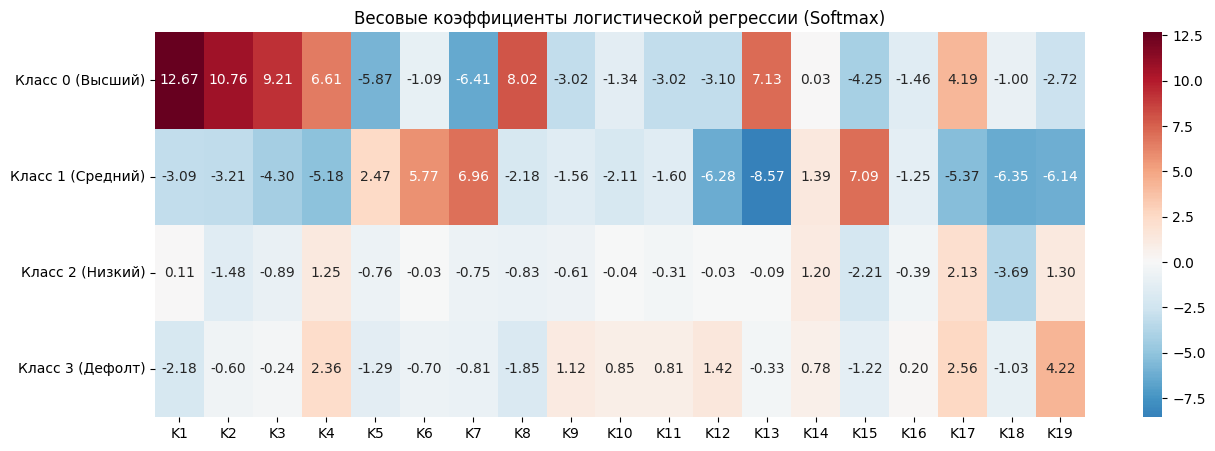

In [42]:
coef_matrix = best_lr.coef_
# coef_matrix - ваш массив 4x19
feature_names = [f'K{i+1}' for i in range(19)]
class_names = ['Класс 0 (Высший)', 'Класс 1 (Средний)', 'Класс 2 (Низкий)', 'Класс 3 (Дефолт)']

df_coef = pd.DataFrame(coef_matrix, index=class_names, columns=feature_names)

plt.figure(figsize=(15, 5))
sns.heatmap(df_coef, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Весовые коэффициенты логистической регрессии (Softmax)')
plt.show()

In [43]:
y_pred = best_lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print(f"accuracy: {accuracy}, precision: {precision}, recall: {recall}, f1: {f1}")

accuracy: 0.934487021013597, precision: 0.9396463956141515, recall: 0.9244996817810732, f1: 0.9318427142138394


In [38]:
confusion_matrix(y_test, y_pred)

array([[ 80,   0,   6,   1],
       [  0, 164,   6,   0],
       [  2,   2, 386,  16],
       [  1,   0,  19, 126]])